# LAB4 : Facial Detection Systems

# Part 2: Facial Detection using Deep Learning

Face detection is a fundamental problem in computer vision and is widely used in applications such as security systems, human–computer interaction, smart surveillance, and biometric authentication. In this assignment, students will implement a deep learning–based facial detection system using a Convolutional Neural Network (CNN).

The goal of this is to understand how neural networks can be trained to classify images as **face** or **non-face**. Students will explore the dataset, train a classifier, evaluate its performance, and visualize the predictions.

students will also briefly observe how machine learning systems may behave differently across different datasets or demographic groups. Understanding such behavior is important for designing responsible and ethical AI systems.

---

## Learning Objectives

After completing this asssignemnt, students should be able to:

- Understand the basic workflow of a computer vision pipeline for facial detection.
- Implement and train a CNN-based binary image classifier. CLO2
- Evaluate the performance of a trained model on test data.
- Visualize and interpret the predictions of a deep learning model.

---

In [2]:
# Import Tensorflow 2.0
import tensorflow as tf

import IPython
import functools
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# # Download and import the MIT 6.S191 package
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl


## 2.1 Datasets

We'll be using three datasets in this lab. In order to train our facial detection models, we'll need a dataset of positive examples (i.e., of faces) and a dataset of negative examples (i.e., of things that are not faces). We'll use these data to train our models to classify images as either faces or not faces. Finally, we'll need a test dataset of face images.

1.   **Positive training data**: [CelebA Dataset](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). A large-scale (over 200K images) of celebrity faces.   
2.   **Negative training data**: [ImageNet](http://www.image-net.org/). Many images across many different categories. We'll take negative examples from a variety of non-human categories.
[Fitzpatrick Scale](https://en.wikipedia.org/wiki/Fitzpatrick_scale) skin type classification system, with each image labeled as "Lighter'' or "Darker''.

Let's begin by importing these datasets. We've written a class that does a bit of data pre-processing to import the training data in a usable format.

In [3]:
# Get the training data: both images from CelebA and ImageNet
path_to_training_data = tf.keras.utils.get_file('train_face.h5', 'https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1')
# Instantiate a TrainingDatasetLoader using the downloaded dataset
loader = mdl.lab2.TrainingDatasetLoader(path_to_training_data)

1263889489/1263889489 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Opening /root/.keras/datasets/train_face.h5
Loading data into memory...


We can look at the size of the training dataset and grab a batch of size 100:

In [4]:
number_of_training_examples = loader.get_train_size()
print(number_of_training_examples)
(images, labels) = loader.get_batch(100)
print(images.shape)
print(labels.shape)

109914
(100, 64, 64, 3)
(100, 1)


Play around with displaying images to get a sense of what the training data actually looks like!

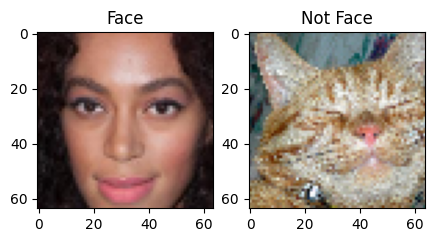

In [7]:
### Examining the CelebA training dataset ###

#@title Change the sliders to look at positive and negative training examples! { run: "auto" }

face_images = images[np.where(labels==1)[0]]
not_face_images = images[np.where(labels==0)[0]]

idx_face = 40 #@param {type:"slider", min:0, max:50, step:1}
idx_not_face = 41 #@param {type:"slider", min:0, max:50, step:1}

plt.figure(figsize=(5,5))
plt.subplot(1, 2, 1)
plt.imshow(face_images[idx_face])
plt.title("Face"); plt.grid(False)

plt.subplot(1, 2, 2)
plt.imshow(not_face_images[idx_not_face])
plt.title("Not Face"); plt.grid(False)

## 2.2 CNN for facial detection

we'll define and train a CNN on the facial classification task, and evaluate its accuracy. The CNN model has a relatively standard architecture consisting of a series of convolutional layers with batch normalization followed by two fully connected layers to flatten the convolution output and generate a class prediction.

The classifier should contain the following layers:

| Layer | Type | Filters / Units | Kernel Size | Stride | Activation |
|------|------|------|------|------|------|
| 1 | Convolution | 12 | 5×5 | 2 | ReLU |
| 2 | Batch Normalization | — | — | — | — |
| 3 | Convolution | 24 | 5×5 | 2 | ReLU |
| 4 | Batch Normalization | — | — | — | — |
| 5 | Convolution | 48 | 3×3 | 2 | ReLU |
| 6 | Batch Normalization | — | — | — | — |
| 7 | Convolution | 72 | 3×3 | 2 | ReLU |
| 8 | Batch Normalization | — | — | — | — |
| 9 | Flatten | — | — | — | — |
| 10 | Dense | 512 | — | — | ReLU |
| 11 | Output Layer | 1 | — | — | Linear |


In [8]:
### Define the CNN model ###
'''TODO1: Use Keras sequential to build the model!'''
n_filters = 12
# Build the CNN classifier
standard_classifier = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=n_filters, kernel_size=5, strides=2, activation='relu', input_shape=(64, 64, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=n_filters * 2, kernel_size=5, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=n_filters * 4, kernel_size=3, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=n_filters * 6, kernel_size=3, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Now let's train the standard CNN!

100%|██████████| 3434/3434 [00:27<00:00, 126.79it/s]


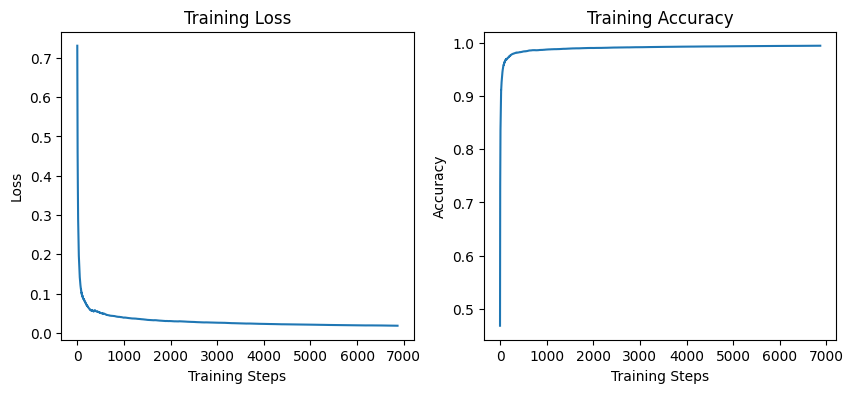

In [9]:
# Training hyperparameters
params = dict(
  batch_size = 32,
  num_epochs = 2,
  learning_rate = 5e-4,
)

# TODO 2: Define optimizer using Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])


# TODO 3: Compile the model
standard_classifier.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

#Train the model using batches from the dataset loader

loss_history = []
acc_history = []

for epoch in range(params["num_epochs"]):

    for step in tqdm(range(loader.get_train_size() // params["batch_size"])): # Use tqdm for progress bar

        images, labels = loader.get_batch(params["batch_size"])

        # TODO 4: train the model using train_on_batch
        loss, acc = standard_classifier.train_on_batch(images, labels)

        # TODO 5: store loss and accuracy values in loss_history and acc_history
        loss_history.append(loss)
        acc_history.append(acc)

# Visualize the training performance
# Plot loss and accuracy curves using matplotlib

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(acc_history)
plt.title("Training Accuracy")
plt.xlabel("Training Steps")
plt.ylabel("Accuracy")

plt.show()

### Evaluate performance of the standard CNN

Next, let's evaluate the classification performance of our CelebA-trained standard CNN on the training dataset.


In [10]:
### Evaluate the CNN classifier ###

# TODO 6: Load a large batch of images and labels from the dataset
# Hint: use loader.get_batch()
num_test_examples = 10000 # Use a reasonable number of examples for evaluation
test_images, true_labels = loader.get_batch(num_test_examples)


# TODO 7: Use the trained CNN model to generate predictions for the images
# Hint: use standard_classifier.predict()
logits = standard_classifier.predict(test_images)


# TODO 8: Convert the logits to probabilities using the sigmoid function
probabilities = tf.sigmoid(logits)


# TODO 9: Convert probabilities into binary predictions (0 or 1)
# Hint: use tf.round()
predictions = tf.round(probabilities)


# TODO 10: Compute the classification accuracy
# Hint: compare predictions with true labels
acc_standard = tf.reduce_mean(tf.cast(tf.equal(predictions, true_labels), tf.float32))


# Print the final accuracy
print("Standard CNN accuracy on training set: {:.4f}".format(acc_standard.numpy()))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Standard CNN accuracy on training set: 0.9730


We will also evaluate our networks on an independent test dataset containing faces that were not seen during training. For the test data, we'll look at the classification accuracy across four different demographics, based on the Fitzpatrick skin scale and sex-based labels: dark-skinned male, dark-skinned female, light-skinned male, and light-skinned female.

Let's take a look at some sample faces in the test set.

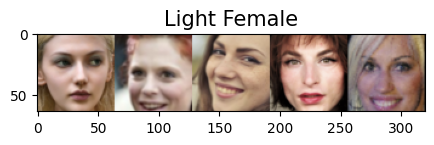

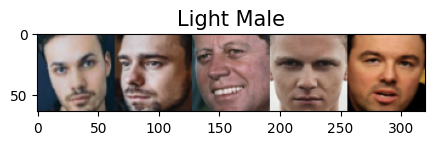

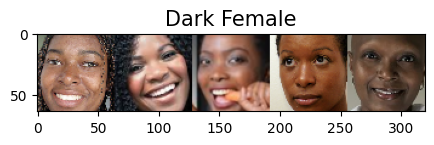

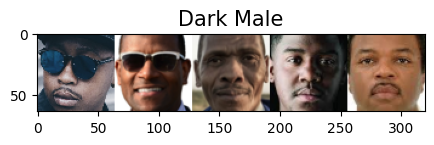

In [11]:
### Load test dataset and plot examples ###

test_faces = mdl.lab2.get_test_faces()
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]
for group, key in zip(test_faces,keys):
  plt.figure(figsize=(5,5))
  plt.imshow(np.hstack(group))
  plt.title(key, fontsize=15)

Now, let's evaluate the probability of each of these face demographics being classified as a face using the standard CNN classifier we've just trained.

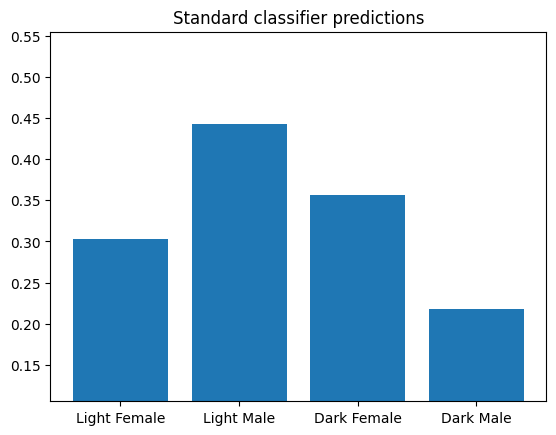

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
### Evaluate the standard CNN on the test data ###

standard_classifier_logits = [standard_classifier(np.array(x, dtype=np.float32)) for x in test_faces]
standard_classifier_probs = tf.squeeze(tf.sigmoid(standard_classifier_logits))

# Plot the prediction accuracies per demographic
xx = range(len(keys))
yy = standard_classifier_probs.numpy().mean(1)
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0,yy.min()-np.ptp(yy)/2.), yy.max()+np.ptp(yy)/2.)
plt.title("Standard classifier predictions");

Take a look at the accuracies for this first model across these four groups. What do you observe? Would you consider this model biased or unbiased? What are some reasons why a trained model may have biased accuracies?

**Answer**

I believe i'm observing the accuracy of the model based on various groups. I would consider this model biased, due to the fact that white males have a much higher accuracy than the other groups, and dark males have a much lower accuracy than the other groups. One of the main reasons a trained model, may have these types of biased accuracies is due to biasness in the dataset itself. If it has more data of one group and lesser of another than its bound to happen that the model will be better at predicting one thing and less at another thing.